# **Setup**

In [3]:
%pip install numpy matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

# **Dataset Selection**

The selected dataset is ideal for Convolutional Neural Networks (CNNs) because distinguishing between white blood cell types relies on detecting local visual patterns rather than fixed geometric positions.

1.  **Texture & Shape Recognition:** Classes are defined by specific textures (cytoplasm granules) and shapes (nucleus lobes vs. round nuclei). CNN filters are designed to automatically learn these edge and texture features.
2.  **Spatial Invariance:** The white blood cell of interest may appear anywhere in the image. CNNs use weight sharing (sliding windows) to detect these features regardless of the cell's location in the frame.

## **Part 1. Dataset Exploration**

In [7]:
base_path = "."
train_search = glob.glob(os.path.join(base_path, "**", "TRAIN"), recursive=True)

if train_search:
    train_path = train_search[0]
    print(f"Found dataset at: {train_path}")

    test_path = train_path.replace("TRAIN", "TEST")
else:
    print("Error: Could not find a 'TRAIN' folder. Please check your folder structure.")

Found dataset at: .\dataset2-master\dataset2-master\images\TRAIN


In [8]:
classes = os.listdir(train_path)
class_counts = {}

print("--- Class Distribution (Training Set) ---")
for class_name in classes:
    class_dir = os.path.join(train_path, class_name)
    if os.path.isdir(class_dir):
        images = os.listdir(class_dir)
        count = len([f for f in images if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = count
        print(f"• {class_name}: {count} images")

counts = list(class_counts.values())
if max(counts) - min(counts) < 200:
    print("\nStatus: The dataset is BALANCED.")
else:
    print("\nStatus: The dataset is IMBALANCED.")

--- Class Distribution (Training Set) ---
• EOSINOPHIL: 2497 images
• LYMPHOCYTE: 2483 images
• MONOCYTE: 2478 images
• NEUTROPHIL: 2499 images

Status: The dataset is BALANCED.


In [9]:
first_class = list(class_counts.keys())[0]
first_img_path = os.path.join(train_path, first_class, os.listdir(os.path.join(train_path, first_class))[0])

with Image.open(first_img_path) as img:
    img_array = np.array(img)
    
    print("--- Image Technical Specs ---")
    print(f"Original Size: {img.size} (Width x Height)")
    print(f"Color Mode:    {img.mode} (RGB means 3 color channels)")
    print(f"Tensor Shape:  {img_array.shape} (Height, Width, Channels)")
    print(f"Pixel Range:   {img_array.min()} to {img_array.max()}")

--- Image Technical Specs ---
Original Size: (320, 240) (Width x Height)
Color Mode:    RGB (RGB means 3 color channels)
Tensor Shape:  (240, 320, 3) (Height, Width, Channels)
Pixel Range:   0 to 255


### **Visualizing Samples**

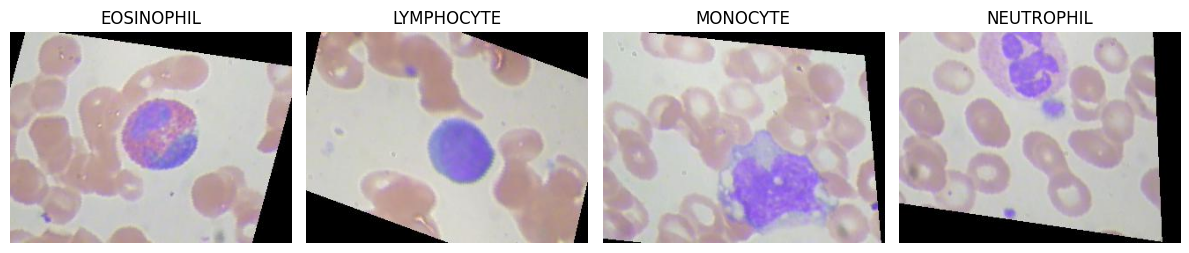

In [10]:
plt.figure(figsize=(12, 4))

for i, class_name in enumerate(class_counts.keys()):
    class_folder = os.path.join(train_path, class_name)

    img_file = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
    img_full_path = os.path.join(class_folder, img_file)

    img = Image.open(img_full_path)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()